## 합성곱 신경망(CNN)

### 구조
* CNN도 신경망과 같이 계층을 조합해 구현 가능
    * 합성곱 계층과 풀링 계층이 등장

* CNN에서는 Conv - RELU - (Pooling) 흐름으로 연결
* 출력에 가까운 층에서는 Affine - ReLU 구성을 사용할 수 있음
* 마지막 출력 계층에서는 Affine - Softmax 조합을 그대로 사용  
=> 일반적인 CNN 구조 

### 합성곱 계층

#### 완전연결 계층의 문제점
* 데이터의 형상이 무시
    * 이미지는 통상 세로, 가로, 채널(색상)로 구성된 3차원 데이터
    * 완전연결 계층에 입력할 때는 3차원 데이터를 1차원 데이터로 바꿔줘야 함
    * 이미지는 3차원 형상이며 이 형상에는 공간적 정보가 담겨 있음  
        => 완전연결 계층은 형상에 담긴 정보를 살릴 수 없음

* 특징 맵: 합성곱 계층의 입출력 데이터

#### 합성곱 연산
* 합성곱 연산은 이미지 처리에서 말하는 필터 연산
* 합성곱 연산은 입력 데이터에 필터를 적용
* 데이터와 필터의 형상을(높이, 너비)로 표기, 필터를 커널이라 칭하기도 함

* 합성곱 연산은 필터의 윈도우를 일정 간격으로 이동해가며 입력 데이터에 적용
* 입력과 필터에서 대응하는 원소끼리 곱한 후 총합을 구함  
=> 단일 곱셈 누산(FMA)
* 그 결과를 출력의 해당 장소에 저장
* 모든 장소에서 수행하면 합성곱 연산의 출력

* CNN에도 편향이 존재
* 편향은 필터를 적용한 후의 데이터에 더해지며 항상 하나(1 x 1)만 존재

#### 패딩
* 합성곱 연산을 수행하기 전 입력 데이터 주변을 특정 값으로 채우기도 함
    -> 패딩
* 패딩은 주로 출력 크기를 조정할 목적으로 사용
* 입력 데이터의 공간적 크기를 고정한 채로 다음 계층에 전달할 수 있음

#### 스트라이드
* 필터를 적용하는 위치의 간격 -> 스트라이드
* 예를 들어 스트라이드를 2로 하면 필터를 적용하는 윈도우가 두 칸씩 이동
* 입력 크기를 (H, W), 필터 크기를 (FH, FW), 출력 크기를 (OH, OW), 패딩을 P, 스트라이드를 S라 하면 출력 크기는
$$
OH = \frac{H + 2P - FH}{S} + 1
$$
$$
OW = \frac{W + 2P - FW}{S} + 1
$$
* 단, 정수로 나눠 떨어지는 값이어야 함

#### 3차원 데이터의 합성곱 연산
* 채널쪽으로 특징 맵이 여러 개 있다면 입력 데이터와 필터의 합성곱 연산을 채널마다 수행하고 그 결과를 더해서 하나의 출력을 얻음
* 합성곱 연산에서 주의할 점은 입력 데이터의 채널 수와 필터의 채널 수가 같아야 함

#### 블록으로 생각하기
* 3차원의 합성곱 연산은 데이터와 필터를 블록이라 생각하면 됨
* (채널수 C, 높이 H, 너비 W) 순서로 씀

* 합성곱 연산의 출력으로 다수의 채널을 내보내려면 필터를 다수 사용
* 필터를 FN개 적용하면 출력도 FN개  
    => (FN, OH, OW)인 블록

* 합성곱 연산에서는 필터의 수도 고려
    * 가중치 데이터는 4차원 데이터이며 (출력 채널 수, 입력 채널 수. 높이, 너비) 순으로 씀

### 배치 처리
* 각 계층을 흐르는 데이터의 차원을 하나 늘려 4차원 데이터로 저장 (데이터 수, 채널 수, 높이, 너비)
* 배치용 차원을 추가해 데이터가 하나 흐를 때마다 데이터 수에 대한 합성곱 연산이 이뤄짐

### 풀링 계층
* 풀링은 세로, 가로 방향의 공간을 줄이는 연산
* 풀링의 윈도우 크기와 스트라이드는 같은 값으로 설정하는 것이 보통

#### 풀링 계층 특징
* 학습해야 할 매개변수가 없음
* 채널 수가 변하지 않음
* 입력의 변화에 영향을 적게 받음

### 합성곱/풀링 계층 구현하기

#### 4차원 배열

In [2]:
import numpy as np

x = np.random.rand(10, 1, 28, 28) # 높이 28, 너비 28, 채널 1인 데이터 10개
print(x.shape)

(10, 1, 28, 28)


In [5]:
print(x[0].shape)
print(x[1].shape)

(1, 28, 28)
(1, 28, 28)


In [8]:
print(x[0, 0].shape) # 첫 번째 데이터의 첫 채널의 공간

(28, 28)


#### im2col로 데이터 전개
* 합성곱 연산을 구현하려면 for문 사용 -> 성능이 떨어짐  
    => im2col 사용  
    - 입력 데이터를 필터링하기 좋게 전개하는 함수
    - 3차원 입력 데이터에 im2col을 적용하면 2차원 행렬로 바뀜



* 대부분 필터의 적용 영역이 겹침 -> 전개 후 원소 수가 원래 블록의 원소 수보다 많아짐  
    => 평소보다 메모리를 많이 소비
* im2col로 입력 데이터를 전개한 다음 합성곱 계층의 필터를 1열로 전개하고 행렬의 내적을 계산

#### 합성곱 계층 구현

In [ ]:
# 인터페이스
im2col(input_data, filter_h, filter_w, stride=1, pad=0)

# input_data: (데이터 수, 채널 수, 높이, 너비)의 4차원 배열로 이루어진 입력 데이터

In [10]:
import sys, os
sys.path.append(os.pardir)
from common.util import im2col

x1 = np.random.rand(1, 3, 7, 7)
col1 = im2col(x1, 5, 5, stride=1, pad=0)
print(col1.shape)

x2 = np.random.rand(10, 3, 7, 7)
col2 = im2col(x2, 5, 5, stride=1, pad=0)
print(col2.shape)

(9, 75)
(90, 75)


In [11]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = 1 + int((H + 2*self.pad - FH) / self.stride)
        out_w = 1 + int((W + 2*self.pad - FW) / self.stride)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T # 필터 전개
        out = np.dot(col, col_W) + self.b

        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        return out

* 필터, 편향, 스트라이드, 패딩을 인수로 받아 초기화
* 필터는 (FN, C, FH, FW)
* 입력 데이터를 im2col로 전개하고 필터도 reshape을 사용해 2차원 배열로 전개한 후 내적
* transpose 함수는 다차원 배열의 축 순서를 바꿈
    * (N, H, W, C) -> (N, C, H, W)

#### 풀링 계층 구현
* 풀링 계층 구현도 im2col을 사용해 입력 데이터를 전개
* 풀링의 경우 채널 쪽이 독립적이라 합성곱 계층 때와 다름
* 전개한 후 행렬에서 행별 최댓값을 구학 적절한 형상으로 성형

In [12]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        # 전개
        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        # 최댓값
        out = np.max(col, axis=1)

        # 성형
        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        return out

### CNN 구현

* Convolution - ReLU - Pooling - Affine - ReLU - Affine - Softmax 순으로

In [19]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import pickle
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient


class SimpleConvNet:
    """단순한 합성곱 신경망
    
    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
    
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]



### CNN 시각화하기

#### 1번째 층의 가중치 시각화하기
* 1번째 층의 합성곱 계층의 가중치는 형상이 (30, 1, 5, 5)

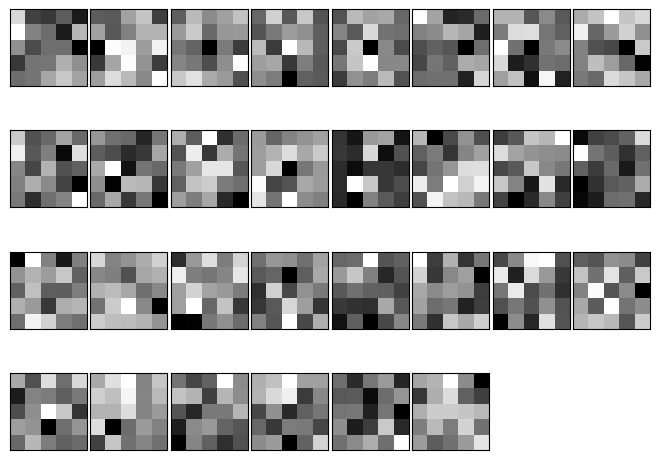

C:\Users\기현\AppData\Local\Temp\ipykernel_16816\526696965.py:101: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  params = pickle.load(f)


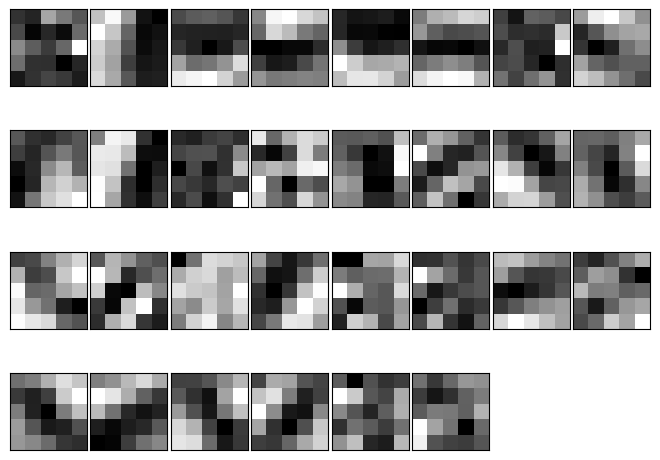

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def filter_show(filters, nx=8, margin=3, scale=10):
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()


network = SimpleConvNet()
# 무작위(랜덤) 초기화 후의 가중치
filter_show(network.params['W1'])

# 학습된 가중치
network.load_params("params.pkl")
filter_show(network.params['W1'])


* 학습 전 필터는 무작위로 초기화되고 있어 흑백의 정도에 규칙성이 없음
* 학습 후 필터는 규칙성 있는 이미지가 됨
* 합성곱 계층의 필터는 에지나 블롭 등의 원시적인 정보를 추출할 수 있음

#### 층 깊이에 따른 추출 정보 변화
* 계층이 깊어질수록 추출되는 정보는 더 추상화
* 층이 깊어지면서 뉴런에 반응하는 대상이 단순한 모양에서 고급 정보로 변화

### 대표적인 CNN

#### LeNet
* 손글씨 숫자를 인식하는 네트워크, 1998년 제안
* 합성곱 계층과 풀링 계층을 반복하고 마지막으로 완전연결 계층을 거치면서 결과를 출력

##### 현재 CNN과의 차이
* 활성화 함수 차이로 LeNet은 시그모이드 함수를 사용, 현재는 ReLU를 사용
* LeNet은 서브샘플링으로 중간 데이터의 크기가 작아지지만, 현재는 최대 풀링이 주류

#### AlexNet
* 2012년 발표
* 합성곱 계층과 풀링 계층을 거듭하며 마지막으로 완전연결 계층을 거쳐 결과를 출력  
    * 활성화 함수로 ReLU 사용
    * LRN이라는 국소적 정규화를 실시하는 계층 이용
    * 드롭아웃을 사용